# 04 - Expense Category Analysis

**Objective:** Identify which expense categories, and which Department x Expense_Category combinations, warrant the closest management attention.

**Business context:** Expense_Category is the closest available dimension to 'product' in this dataset. This notebook replaces the originally-planned product-profitability notebook for that reason.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from data_loading import load_dataset
from data_cleaning import clean_dataset
from feature_engineering import engineer_features
import kpi_calculations as kpi


In [2]:
raw = load_dataset()
cleaned, _ = clean_dataset(raw)
df = engineer_features(cleaned)
by_cat = kpi.kpis_by_expense_category(df)
by_cat.round(4)

,total_allocated,total_utilized,supplied_budget_variance,avg_allocation_efficiency,record_count,utilization_rate,computed_budget_gap
expense_category,,,,,,,
Technology,1.772800e+08,1.678907e+08,98429.24,84.2513,1165,0.9470,9389273.49
Operations,1.713672e+08,1.629306e+08,-43070.80,84.0764,1139,0.9508,8436613.22
Training,1.710734e+08,1.649443e+08,141282.17,83.8552,1133,0.9642,6129131.26
Maintenance,1.691686e+08,1.586176e+08,11872.63,83.9543,1119,0.9376,10551035.24
Infrastructure,1.674453e+08,1.643016e+08,-523992.75,84.0535,1131,0.9812,3143682.14
Salaries,1.634485e+08,1.601989e+08,-44684.48,84.0574,1093,0.9801,3249561.33


## Q: Which expense categories consume the most budget?

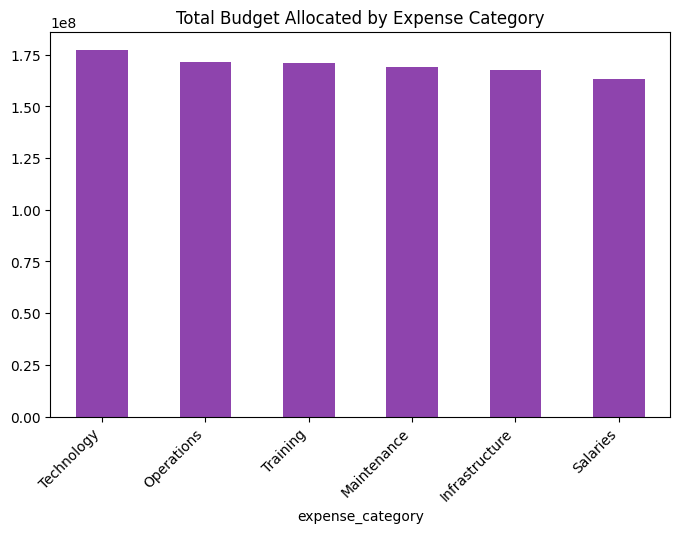

In [3]:
fig, ax = plt.subplots(figsize=(8,5))
by_cat['total_allocated'].plot(kind='bar', ax=ax, color='#8e44ad')
ax.set_title('Total Budget Allocated by Expense Category')
plt.xticks(rotation=45, ha='right')
plt.show()

## Q: Which Department x Expense_Category combinations run hottest (highest utilization)?

In [4]:
top10 = kpi.top_overspent_department_category(df, 10)
top10.round(4)

,department,expense_category,utilization_rate
2,Finance,Operations,1.3002
15,IT,Salaries,1.2612
5,Finance,Training,1.2588
43,Sales,Maintenance,1.2551
3,Finance,Salaries,1.2532
19,Logistics,Maintenance,1.2523
41,R&D,Training,1.2489
36,R&D,Infrastructure,1.2480
39,R&D,Salaries,1.2431
6,HR,Infrastructure,1.2425


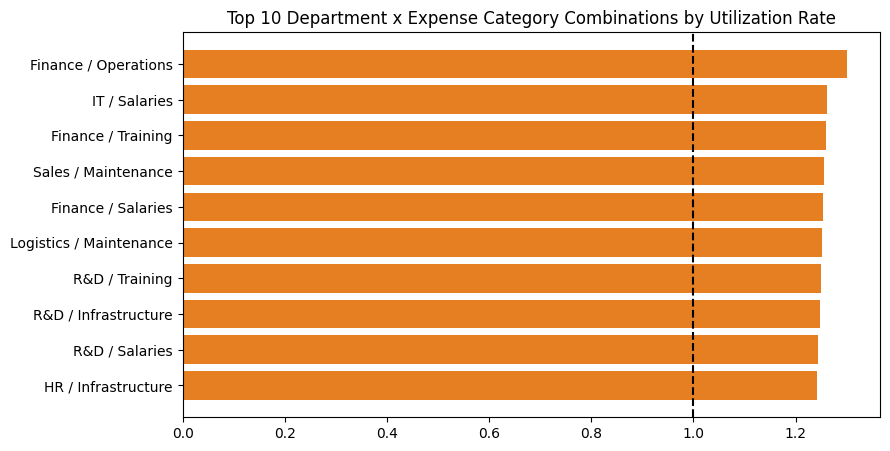

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
labels = top10['department'].astype(str) + ' / ' + top10['expense_category'].astype(str)
ax.barh(labels, top10['utilization_rate'], color='#e67e22')
ax.axvline(1.0, color='black', linestyle='--')
ax.invert_yaxis()
ax.set_title('Top 10 Department x Expense Category Combinations by Utilization Rate')
plt.show()

## Findings

- Technology is the largest expense category by total allocation (~$177.3M), followed by Operations (~$171.4M) and Training (~$171.1M).
- The three highest-utilization combinations are Finance/Operations (130.0%), IT/Salaries (126.1%), and Finance/Training (125.9%) - these are the strongest candidates for a targeted budget review rather than portfolio-wide action. See `docs/findings.md` Finding 3 and `docs/recommendations.md` recommendation 1.